# 🔬 Beta-Thalassemia (Minor) Detection — YOLOv8s Training
### HEMORA Project | Blood Smear Image Analysis
**Model:** YOLOv8s | **Classes:** target_cell, hypochromic_cell, microcyte

---
### Notebook Sections:
1. GPU Check  
2. Mount Google Drive & Create Folders  
3. Install Dependencies  
4. Upload & Extract Dataset  
5. Verify Dataset  
6. Preprocessing (Stain Normalization)  
7. Train YOLOv8s  
8. Plot Training Graphs  
9. Save Per-Epoch Log  
10. Save Best Model  
11. Test Predictions  
12. ResNet50 Classifier  
13. Hybrid Inference Pipeline  
14. Drive Verification & Demo  
---

## ✅ STEP 1 — Check GPU

In [ ]:
import torch
print('='*50)
print('GPU INFORMATION')
print('='*50)
print(f'CUDA Available: {torch.cuda.is_available()}')
if torch.cuda.is_available():
    print(f'GPU Name: {torch.cuda.get_device_name(0)}')
    print(f'GPU Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')
else:
    print('No GPU! Go to Runtime > Change Runtime Type > GPU')
print('='*50)
!nvidia-smi

GPU INFORMATION
CUDA Available: True
GPU Name: Tesla T4
GPU Memory: 15.6 GB
Fri Mar  6 05:57:25 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   37C    P8             11W /   70W |       3MiB /  15360MiB |      0%      Default |
|                                         |                     

## ✅ STEP 2 — Mount Google Drive

In [2]:
from google.colab import drive
drive.mount('/content/drive')
print('✅ Google Drive mounted!')

Mounted at /content/drive
✅ Google Drive mounted!


In [ ]:
import os

BASE_DIR = '/content/drive/MyDrive/thalassemia_project'

folders = [
    f'{BASE_DIR}/dataset',
    f'{BASE_DIR}/models/yolo',
    f'{BASE_DIR}/models/resnet',
    f'{BASE_DIR}/graphs/yolo',
    f'{BASE_DIR}/graphs/resnet',
    f'{BASE_DIR}/predictions/yolo',
    f'{BASE_DIR}/training_logs',
    f'{BASE_DIR}/confusion_matrix',
    f'{BASE_DIR}/roc_curves',
]

for folder in folders:
    os.makedirs(folder, exist_ok=True)
    print(f'✅ Created: {folder}')

print('\n🎉 All project folders created in Google Drive!')

✅ Created: /content/drive/MyDrive/thalassemia_project/dataset
✅ Created: /content/drive/MyDrive/thalassemia_project/models/yolo
✅ Created: /content/drive/MyDrive/thalassemia_project/models/resnet
✅ Created: /content/drive/MyDrive/thalassemia_project/graphs/yolo
✅ Created: /content/drive/MyDrive/thalassemia_project/graphs/resnet
✅ Created: /content/drive/MyDrive/thalassemia_project/predictions/yolo
✅ Created: /content/drive/MyDrive/thalassemia_project/training_logs
✅ Created: /content/drive/MyDrive/thalassemia_project/confusion_matrix
✅ Created: /content/drive/MyDrive/thalassemia_project/roc_curves

🎉 All project folders created in Google Drive!


## ✅ STEP 3 — Install Dependencies

In [ ]:
!pip install ultralytics -q
!pip install matplotlib seaborn scikit-learn opencv-python-headless -q
!pip install albumentations -q

import ultralytics
print(f'Ultralytics version: {ultralytics.__version__}')
print('✅ All packages installed!')

Ultralytics version: 8.4.21
✅ All packages installed!


In [ ]:
import os, shutil, zipfile, yaml, json, time, glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
from datetime import datetime
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
import torchvision.transforms as transforms
from torchvision import models
from torchvision.datasets import ImageFolder
from torch.optim.lr_scheduler import ReduceLROnPlateau
from ultralytics import YOLO
from google.colab import files
from PIL import Image
from matplotlib.patches import Patch

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')
torch.manual_seed(42)
np.random.seed(42)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'✅ All libraries imported!')
print(f'PyTorch: {torch.__version__}  |  Device: {device}')

✅ All libraries imported!
PyTorch: 2.10.0+cu128  |  Device: cuda


## ✅ STEP 4 — Upload & Extract Roboflow Dataset ZIP

In [ ]:
print('📂 Please upload your Roboflow dataset ZIP file...')
uploaded = files.upload()
zip_filename = list(uploaded.keys())[0]
print(f'✅ Uploaded: {zip_filename}')

📂 Please upload your Roboflow dataset ZIP file...


Saving thalassemia_dataset_upload.zip to thalassemia_dataset_upload.zip
✅ Uploaded: thalassemia_dataset_upload.zip


In [ ]:
DATASET_DIR = '/content/thalassemia_dataset'
os.makedirs(DATASET_DIR, exist_ok=True)

with zipfile.ZipFile(zip_filename, 'r') as z:
    z.extractall(DATASET_DIR)

print(f'✅ Extracted to: {DATASET_DIR}')
print('\n📁 Dataset structure:')
for root, dirs, fs in os.walk(DATASET_DIR):
    level = root.replace(DATASET_DIR, '').count(os.sep)
    if level > 2:
        continue
    indent = '  ' * level
    print(f'{indent}{os.path.basename(root)}/')
    if level < 2:
        sub = '  ' * (level + 1)
        for f in fs[:3]:
            print(f'{sub}{f}')

✅ Extracted to: /content/thalassemia_dataset

📁 Dataset structure:
thalassemia_dataset/
  data.yaml
  README.roboflow.txt
  train/
    labels/
    images/
  valid/
    labels/
    images/
  test/
    labels/
    images/


## ✅ STEP 5 — Verify & Fix Dataset

In [ ]:
yaml_files = glob.glob(f'{DATASET_DIR}/**/*.yaml', recursive=True)
print(f'Found YAML: {yaml_files}')
DATA_YAML = yaml_files[0] if yaml_files else f'{DATASET_DIR}/data.yaml'

with open(DATA_YAML, 'r') as f:
    data_config = yaml.safe_load(f)

print('\nCurrent data.yaml:')
print(yaml.dump(data_config, default_flow_style=False))

Found YAML: ['/content/thalassemia_dataset/data.yaml']

Current data.yaml:
names:
- hypochromic_cell
- microcyte
- target_cell
nc: 3
roboflow:
  license: Private
  project: beta-thalassemia-detection-data
  url: https://app.roboflow.com/oshans-workspace/beta-thalassemia-detection-data/1
  version: 1
  workspace: oshans-workspace
test: ../test/images
train: ../train/images
val: ../valid/images



In [ ]:
yaml_dir = os.path.dirname(DATA_YAML)

# Fix paths to absolute
data_config['train'] = f'{yaml_dir}/train/images'
data_config['val']   = f'{yaml_dir}/valid/images'

test_path = f'{yaml_dir}/test/images'
if os.path.exists(test_path):
    data_config['test'] = test_path

with open(DATA_YAML, 'w') as f:
    yaml.dump(data_config, f, default_flow_style=False)

print('✅ data.yaml paths fixed!')
with open(DATA_YAML, 'r') as f:
    print(f.read())

✅ data.yaml paths fixed!
names:
- hypochromic_cell
- microcyte
- target_cell
nc: 3
roboflow:
  license: Private
  project: beta-thalassemia-detection-data
  url: https://app.roboflow.com/oshans-workspace/beta-thalassemia-detection-data/1
  version: 1
  workspace: oshans-workspace
test: /content/thalassemia_dataset/test/images
train: /content/thalassemia_dataset/train/images
val: /content/thalassemia_dataset/valid/images



In [ ]:
# ============================================================
# ✅ LOAD CLASS NAMES DIRECTLY FROM data.yaml
# This ensures correct order matching Roboflow export
# Correct order: 0=hypochromic_cell | 1=microcyte | 2=target_cell
# ============================================================
with open(DATA_YAML, 'r') as f:
    config = yaml.safe_load(f)

CLASS_NAMES = config['names']
NUM_CLASSES = config['nc']

print('='*45)
print('✅ Class names loaded from data.yaml:')
for i, name in enumerate(CLASS_NAMES):
    print(f'   {i} → {name}')
print('='*45)

# ── Colors mapped to CORRECT class order ──
# 0=hypochromic_cell → Green
# 1=microcyte        → Blue
# 2=target_cell      → Red
COLORS_RGB = {
    0: (50,  200, 50),   # hypochromic_cell → Green
    1: (50,  100, 255),  # microcyte        → Blue
    2: (255, 50,  50),   # target_cell      → Red
}

print('\n✅ Color mapping:')
for cls_id, color in COLORS_RGB.items():
    print(f'   {cls_id} → {CLASS_NAMES[cls_id]} → RGB{color}')

✅ Class names loaded from data.yaml:
   0 → hypochromic_cell
   1 → microcyte
   2 → target_cell

✅ Color mapping:
   0 → hypochromic_cell → RGB(50, 200, 50)
   1 → microcyte → RGB(50, 100, 255)
   2 → target_cell → RGB(255, 50, 50)


In [ ]:
splits = ['train', 'valid', 'test']
print('='*60)
print('DATASET STATISTICS')
print('='*60)

for split in splits:
    img_path = f'{yaml_dir}/{split}/images'
    lbl_path = f'{yaml_dir}/{split}/labels'
    if not os.path.exists(img_path):
        continue
    images = [f for f in os.listdir(img_path) if f.endswith(('.jpg','.jpeg','.png'))]
    labels = [f for f in os.listdir(lbl_path) if f.endswith('.txt')] if os.path.exists(lbl_path) else []

    class_counts = {i: 0 for i in range(NUM_CLASSES)}
    for lbl in labels:
        with open(f'{lbl_path}/{lbl}') as f:
            for line in f:
                line = line.strip()
                if line:
                    cls_id = int(line.split()[0])
                    if cls_id in class_counts:
                        class_counts[cls_id] += 1

    print(f'\n{split.upper()}: {len(images)} images | {len(labels)} labels')
    for i in range(NUM_CLASSES):
        print(f'   {CLASS_NAMES[i]}: {class_counts[i]} annotations')

print('\n' + '='*60)

DATASET STATISTICS

TRAIN: 304 images | 304 labels
   hypochromic_cell: 2752 annotations
   microcyte: 352 annotations
   target_cell: 1499 annotations

VALID: 4 images | 4 labels
   hypochromic_cell: 28 annotations
   microcyte: 0 annotations
   target_cell: 31 annotations

TEST: 3 images | 3 labels
   hypochromic_cell: 33 annotations
   microcyte: 0 annotations
   target_cell: 35 annotations



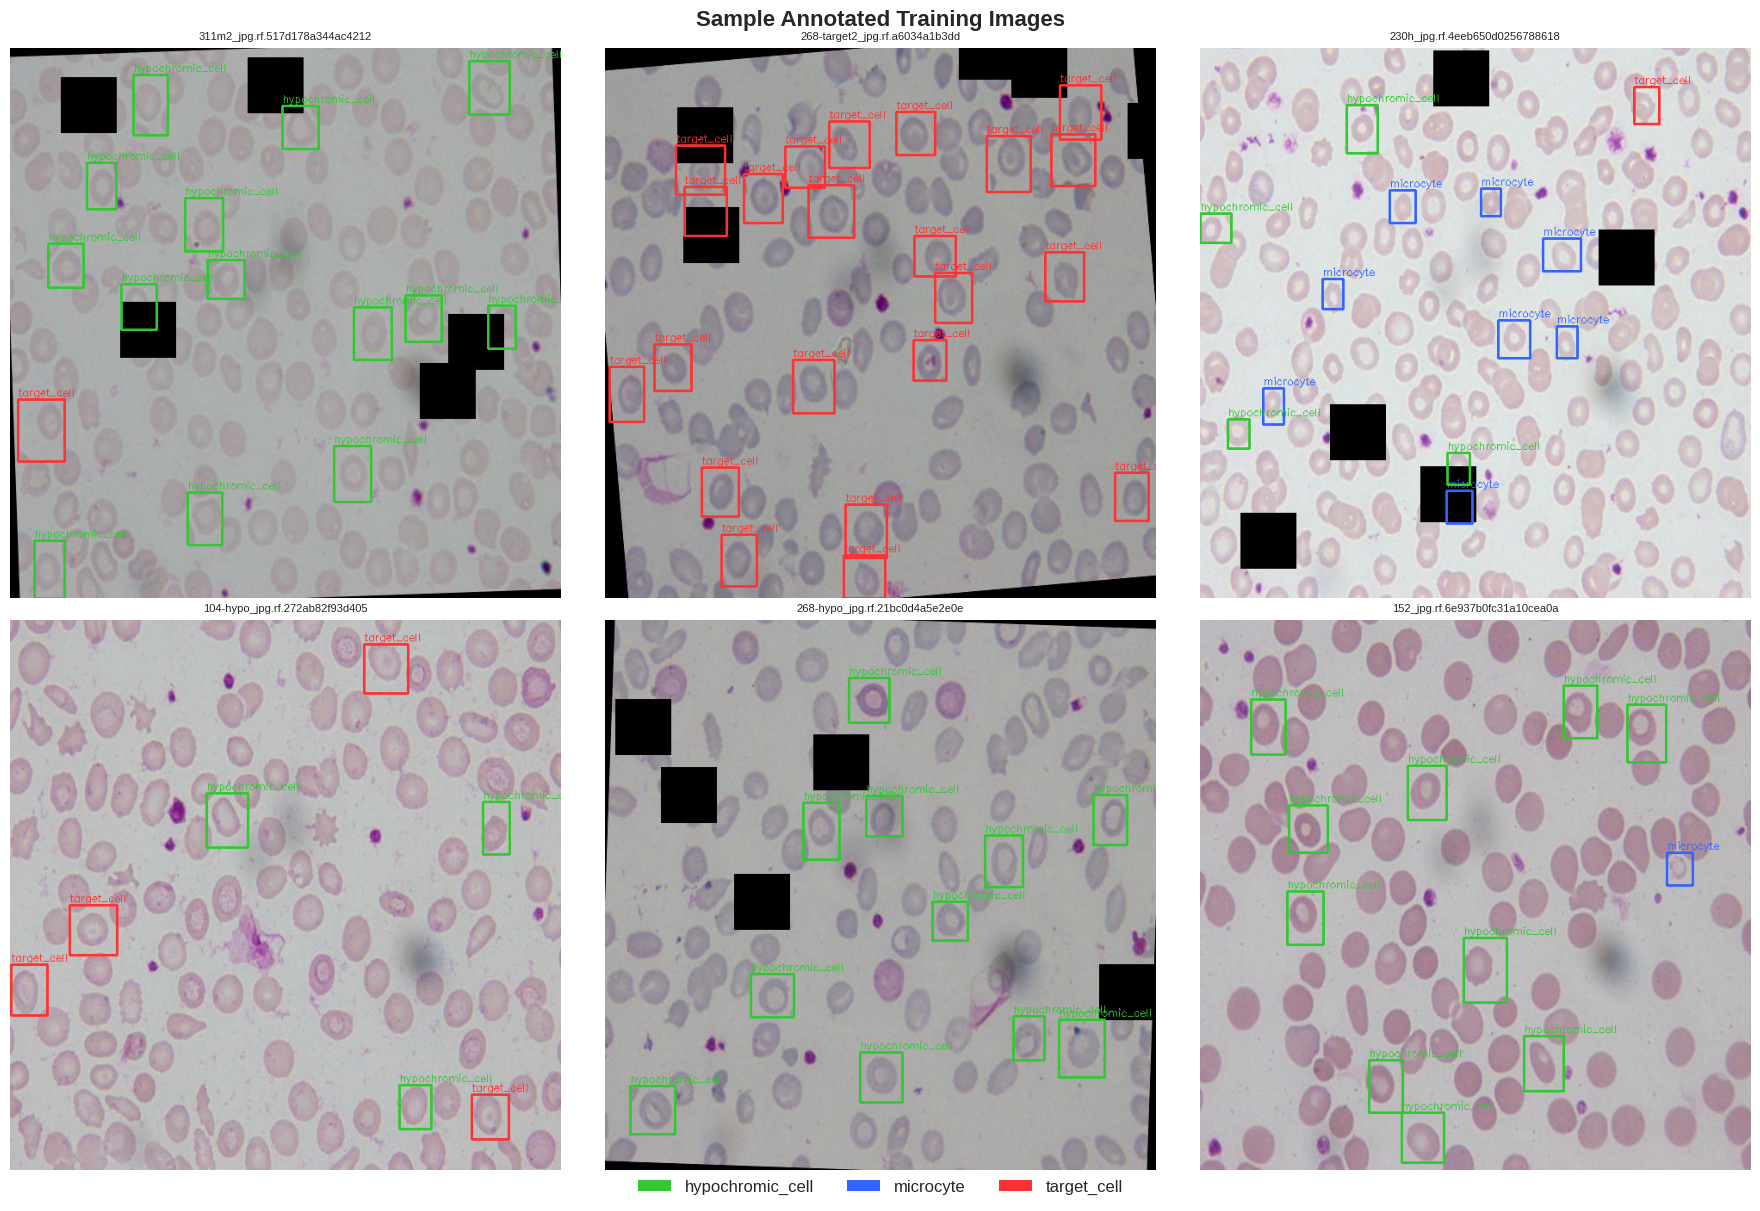

✅ Sample annotations saved to Drive!


In [ ]:
train_img_dir = f'{yaml_dir}/train/images'
train_lbl_dir = f'{yaml_dir}/train/labels'
sample_imgs   = [f for f in os.listdir(train_img_dir)
                 if f.endswith(('.jpg','.jpeg','.png'))][:6]

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

for idx, img_file in enumerate(sample_imgs):
    img = cv2.cvtColor(cv2.imread(f'{train_img_dir}/{img_file}'), cv2.COLOR_BGR2RGB)
    h, w = img.shape[:2]
    lbl_path = f'{train_lbl_dir}/{os.path.splitext(img_file)[0]}.txt'

    if os.path.exists(lbl_path):
        with open(lbl_path) as f:
            for line in f:
                p = line.strip().split()
                if len(p) == 5:
                    cls = int(p[0])
                    cx, cy, bw, bh = float(p[1]), float(p[2]), float(p[3]), float(p[4])
                    x1, y1 = int((cx - bw/2)*w), int((cy - bh/2)*h)
                    x2, y2 = int((cx + bw/2)*w), int((cy + bh/2)*h)
                    c = COLORS_RGB.get(cls, (255, 255, 0))
                    cv2.rectangle(img, (x1,y1), (x2,y2), c, 2)
                    label = CLASS_NAMES[cls] if cls < NUM_CLASSES else str(cls)
                    cv2.putText(img, label, (x1, y1-4),
                                cv2.FONT_HERSHEY_SIMPLEX, 0.4, c, 1)

    axes[idx].imshow(img)
    axes[idx].set_title(img_file[:30], fontsize=8)
    axes[idx].axis('off')

# Legend using actual class names and colors
legend_elements = [
    Patch(facecolor=[c/255 for c in COLORS_RGB[i]], label=CLASS_NAMES[i])
    for i in range(NUM_CLASSES)
]
fig.legend(handles=legend_elements, loc='lower center',
           ncol=3, fontsize=12, bbox_to_anchor=(0.5, -0.02))

plt.suptitle('Sample Annotated Training Images', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{BASE_DIR}/graphs/yolo/sample_annotations.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Sample annotations saved to Drive!')

## ✅ STEP 6 — Stain Normalization (Preprocessing)

✅ Preprocessing functions ready (Macenko + CLAHE)


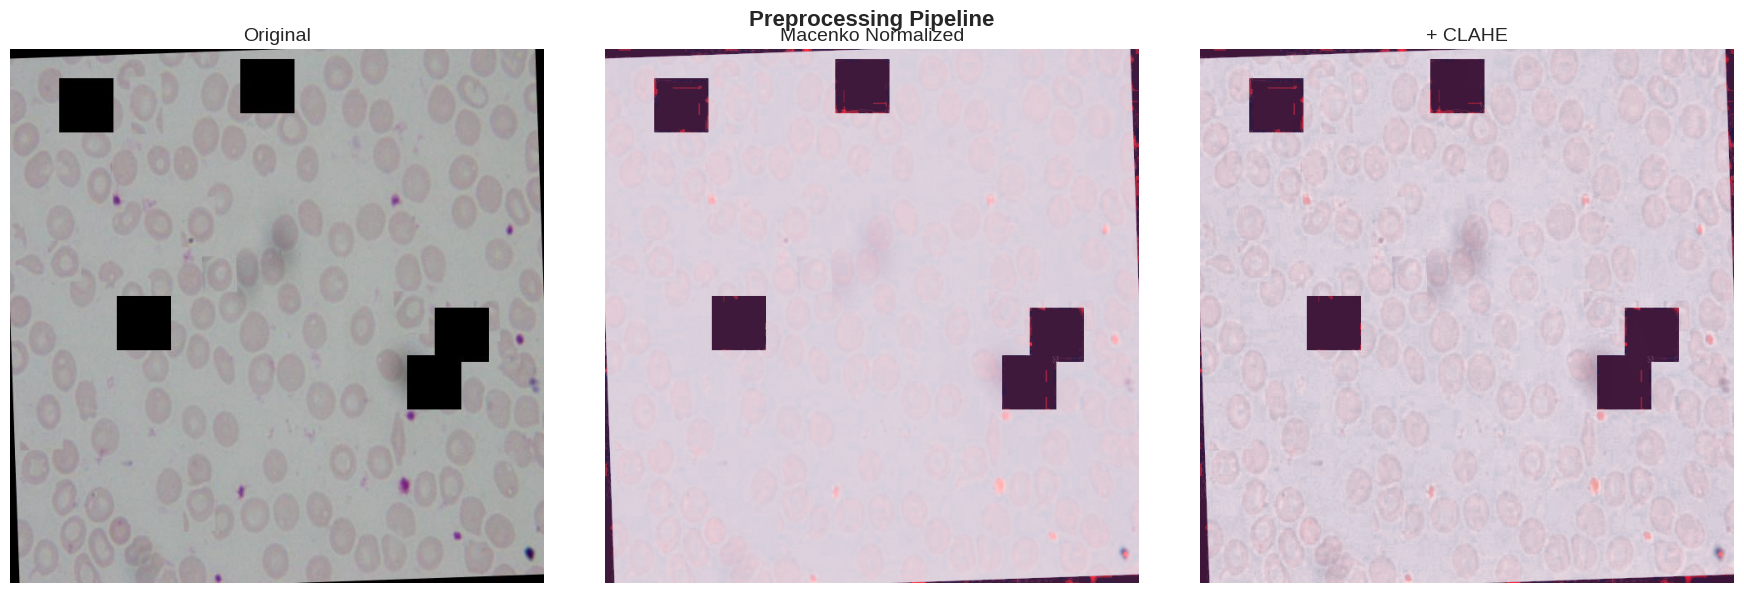

✅ Preprocessing comparison saved!


In [ ]:
def macenko_normalize(image, Io=240, alpha=1, beta=0.15):
    try:
        I = image.astype(np.float64)
        I[I == 0] = 1
        OD = -np.log(I / Io)
        OD_hat = OD.reshape(-1, 3)
        OD_hat = OD_hat[np.all(OD_hat > beta, axis=1)]
        if len(OD_hat) < 10:
            return image
        _, V = np.linalg.eigh(np.cov(OD_hat.T))
        V = V[:, [2, 1]]
        if V[0,0] < 0: V[:,0] *= -1
        if V[0,1] < 0: V[:,1] *= -1
        That = OD_hat @ V
        phi  = np.arctan2(That[:,1], That[:,0])
        vMin = V @ np.array([np.cos(np.percentile(phi, alpha)),
                              np.sin(np.percentile(phi, alpha))])
        vMax = V @ np.array([np.cos(np.percentile(phi, 100-alpha)),
                              np.sin(np.percentile(phi, 100-alpha))])
        HE = np.array([vMin, vMax]).T if vMin[0] > vMax[0] else np.array([vMax, vMin]).T
        OD_flat = OD.reshape(-1, 3)
        C = np.linalg.lstsq(HE, OD_flat.T, rcond=None)[0]
        maxC    = np.percentile(C, 99, axis=1)
        maxCRef = np.array([1.9705, 1.0308])
        C       = C / maxC[:, np.newaxis] * maxCRef[:, np.newaxis]
        HERef   = np.array([[0.5626,0.2159],[0.7201,0.8012],[0.4062,0.5581]])
        Inorm   = Io * np.exp(-HERef @ C)
        Inorm   = Inorm.T.reshape(image.shape)
        return np.clip(Inorm, 0, 255).astype(np.uint8)
    except:
        return image

def apply_clahe(image):
    lab = cv2.cvtColor(image, cv2.COLOR_RGB2LAB)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
    lab[:,:,0] = clahe.apply(lab[:,:,0])
    return cv2.cvtColor(lab, cv2.COLOR_LAB2RGB)

print('✅ Preprocessing functions ready (Macenko + CLAHE)')

sample_file = [f for f in os.listdir(train_img_dir)
               if f.endswith(('.jpg','.jpeg','.png'))][0]
sample_rgb  = cv2.cvtColor(cv2.imread(f'{train_img_dir}/{sample_file}'), cv2.COLOR_BGR2RGB)
norm        = macenko_normalize(sample_rgb)
enh         = apply_clahe(norm)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
for ax, img, title in zip(axes,
                           [sample_rgb, norm, enh],
                           ['Original', 'Macenko Normalized', '+ CLAHE']):
    ax.imshow(img); ax.set_title(title, fontsize=14); ax.axis('off')

plt.suptitle('Preprocessing Pipeline', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{BASE_DIR}/graphs/yolo/preprocessing.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Preprocessing comparison saved!')

## ✅ STEP 7 — Train YOLOv8s 🚀

In [ ]:
YOLO_SAVE_DIR = '/content/yolo_results'
os.makedirs(YOLO_SAVE_DIR, exist_ok=True)

EPOCHS     = 100
BATCH_SIZE = 16
IMG_SIZE   = 640
PATIENCE   = 20
LR0        = 0.01
LRF        = 0.001

print('='*50)
print('YOLOV8s TRAINING CONFIG')
print('='*50)
print(f'Classes    : {CLASS_NAMES}')
print(f'Epochs     : {EPOCHS}')
print(f'Batch Size : {BATCH_SIZE}')
print(f'Image Size : {IMG_SIZE}')
print(f'Optimizer  : AdamW + Cosine LR')
print(f'Early Stop : patience={PATIENCE}')
print('='*50)

YOLOV8s TRAINING CONFIG
Classes    : ['hypochromic_cell', 'microcyte', 'target_cell']
Epochs     : 100
Batch Size : 16
Image Size : 640
Optimizer  : AdamW + Cosine LR
Early Stop : patience=20


In [ ]:
yolo_model = YOLO('yolov8s.pt')
print('✅ YOLOv8s pretrained weights loaded!')

start_time = time.time()
print('\n🚀 Training started...')

results = yolo_model.train(
    data=DATA_YAML,
    epochs=EPOCHS,
    imgsz=IMG_SIZE,
    batch=BATCH_SIZE,
    patience=PATIENCE,
    lr0=LR0,
    lrf=LRF,
    optimizer='AdamW',
    cos_lr=True,
    augment=True,
    mosaic=1.0,
    mixup=0.1,
    copy_paste=0.1,
    degrees=15.0,
    flipud=0.5,
    fliplr=0.5,
    hsv_h=0.015,
    hsv_s=0.7,
    hsv_v=0.4,
    warmup_epochs=3,
    weight_decay=0.0005,
    dropout=0.1,
    val=True,
    save=True,
    save_period=10,
    project=YOLO_SAVE_DIR,
    name='thalassemia_yolov8s',
    exist_ok=True,
    pretrained=True,
    verbose=True,
    seed=42,
    workers=2,
    device=0 if torch.cuda.is_available() else 'cpu',
)

training_time = time.time() - start_time
print(f'\n✅ Training Complete! Time: {training_time/60:.1f} minutes')

✅ YOLOv8s pretrained weights loaded!

🚀 Training started...
Ultralytics 8.4.21 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=True, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.1, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=/content/thalassemia_dataset/data.yaml, degrees=15.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.1, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.5, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.001, mask_ratio=4, max_det=300, mixup=0.1, mode=train, model=yolov8s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=thalassemia_yolov8s, nbs=64, nms=False, opset=No

## ✅ STEP 8 — Plot & Save All Training Graphs

In [ ]:
results_dir = f'{YOLO_SAVE_DIR}/thalassemia_yolov8s'
df = pd.read_csv(f'{results_dir}/results.csv')
df.columns = df.columns.str.strip()
print(f'✅ Loaded results.csv — {len(df)} epochs')
print('Columns:', list(df.columns))
df.tail(5)

✅ Loaded results.csv — 88 epochs
Columns: ['epoch', 'time', 'train/box_loss', 'train/cls_loss', 'train/dfl_loss', 'metrics/precision(B)', 'metrics/recall(B)', 'metrics/mAP50(B)', 'metrics/mAP50-95(B)', 'val/box_loss', 'val/cls_loss', 'val/dfl_loss', 'lr/pg0', 'lr/pg1', 'lr/pg2']


,epoch,time,train/box_loss,train/cls_loss,train/dfl_loss,metrics/precision(B),metrics/recall(B),metrics/mAP50(B),metrics/mAP50-95(B),val/box_loss,val/cls_loss,val/dfl_loss,lr/pg0,lr/pg1,lr/pg2
83,84,565.783,1.40298,1.23282,1.29411,0.58555,0.67108,0.62057,0.27436,1.98617,1.41920,1.68367,0.000706,0.000706,0.000706
84,85,572.784,1.40823,1.25037,1.30994,0.56023,0.69077,0.62825,0.27760,2.00497,1.27646,1.69361,0.000628,0.000628,0.000628
85,86,579.085,1.39560,1.26870,1.30893,0.60159,0.62283,0.63360,0.27327,1.97977,1.32156,1.69560,0.000554,0.000554,0.000554
86,87,586.299,1.41717,1.23173,1.30647,0.57462,0.67794,0.60739,0.27011,1.89054,1.41673,1.65398,0.000485,0.000485,0.000485
87,88,592.431,1.35615,1.21230,1.27453,0.59334,0.69560,0.62593,0.27915,1.91391,1.40717,1.65579,0.000421,0.000421,0.000421


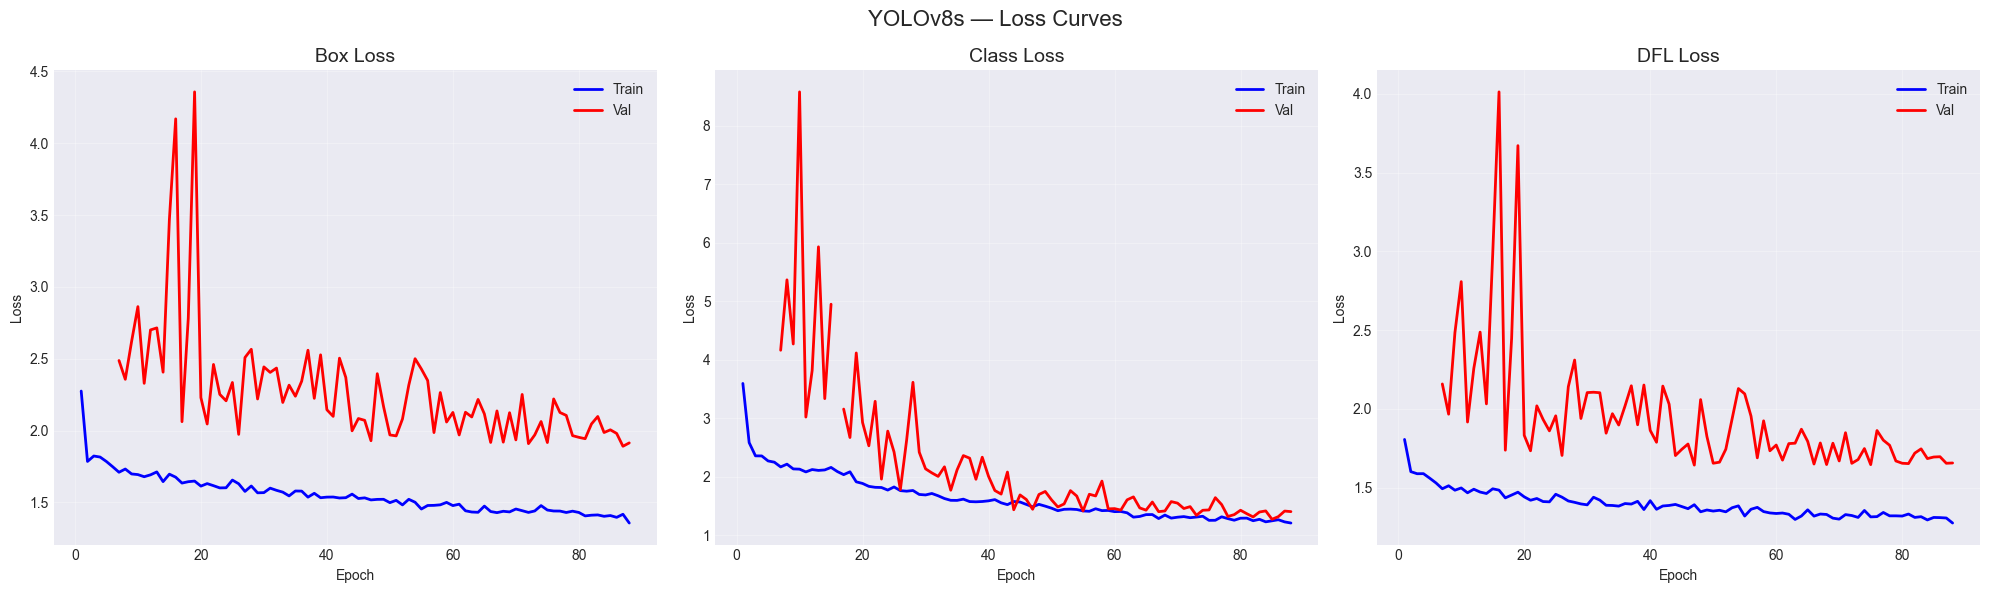

✅ Loss curves saved!


In [ ]:
epochs_range = range(1, len(df)+1)

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
for ax, (tr, vl, title) in zip(axes, [
    ('train/box_loss', 'val/box_loss', 'Box Loss'),
    ('train/cls_loss', 'val/cls_loss', 'Class Loss'),
    ('train/dfl_loss', 'val/dfl_loss', 'DFL Loss'),
]):
    ax.plot(epochs_range, df[tr], 'b-', label='Train', linewidth=2)
    ax.plot(epochs_range, df[vl], 'r-', label='Val',   linewidth=2)
    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.set_xlabel('Epoch'); ax.set_ylabel('Loss')
    ax.legend(); ax.grid(True, alpha=0.3)

plt.suptitle('YOLOv8s — Loss Curves', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{BASE_DIR}/graphs/yolo/loss_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Loss curves saved!')

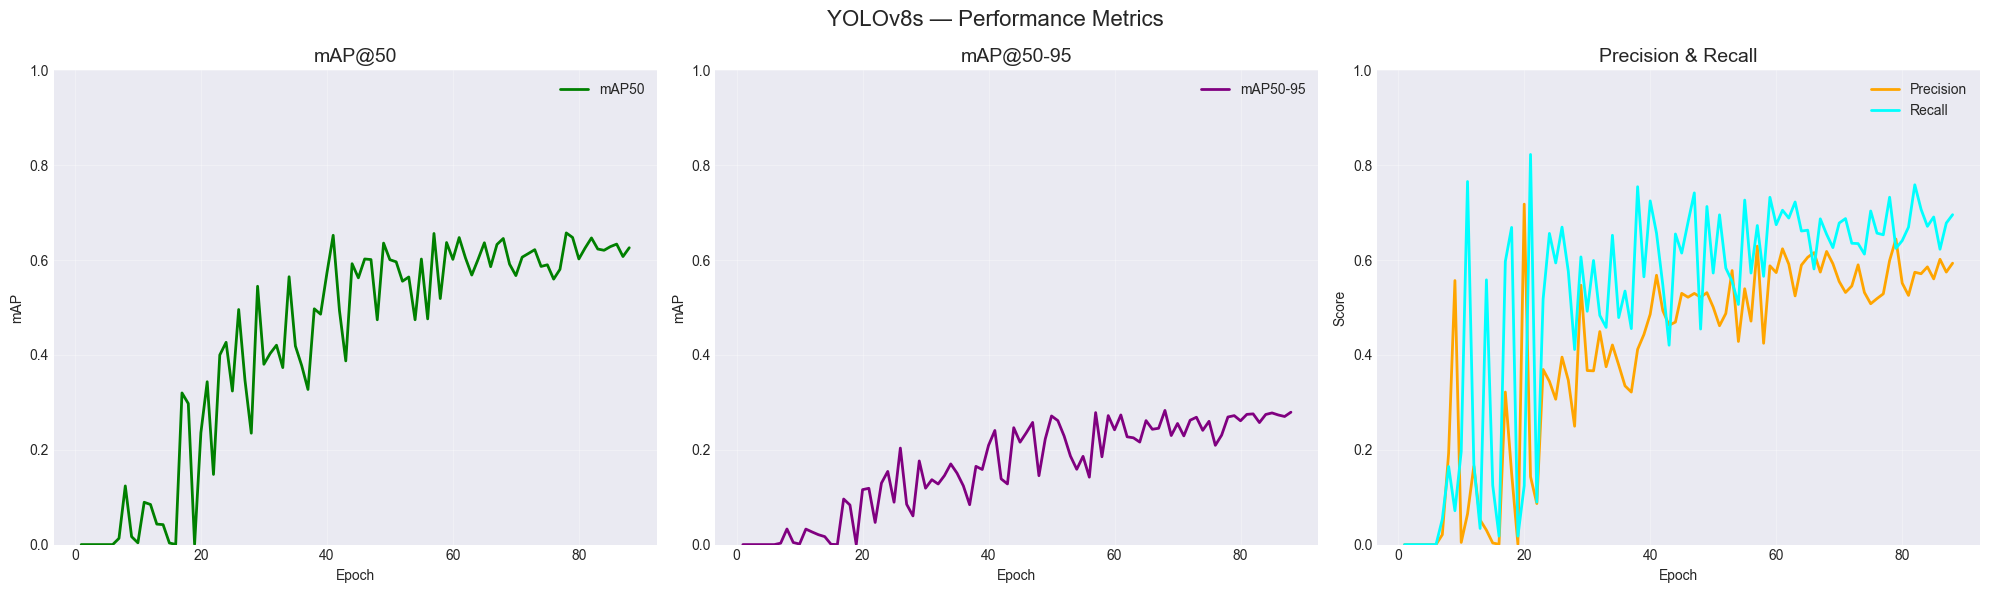

✅ Performance metrics saved!


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

axes[0].plot(epochs_range, df['metrics/mAP50(B)'],    'g-', linewidth=2, label='mAP50')
axes[0].set_title('mAP@50', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('mAP')
axes[0].set_ylim([0,1]); axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].plot(epochs_range, df['metrics/mAP50-95(B)'], 'purple', linewidth=2, label='mAP50-95')
axes[1].set_title('mAP@50-95', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('mAP')
axes[1].set_ylim([0,1]); axes[1].legend(); axes[1].grid(True, alpha=0.3)

axes[2].plot(epochs_range, df['metrics/precision(B)'], 'orange', linewidth=2, label='Precision')
axes[2].plot(epochs_range, df['metrics/recall(B)'],    'cyan',   linewidth=2, label='Recall')
axes[2].set_title('Precision & Recall', fontsize=14, fontweight='bold')
axes[2].set_xlabel('Epoch'); axes[2].set_ylabel('Score')
axes[2].set_ylim([0,1]); axes[2].legend(); axes[2].grid(True, alpha=0.3)

plt.suptitle('YOLOv8s — Performance Metrics', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{BASE_DIR}/graphs/yolo/performance_metrics.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Performance metrics saved!')

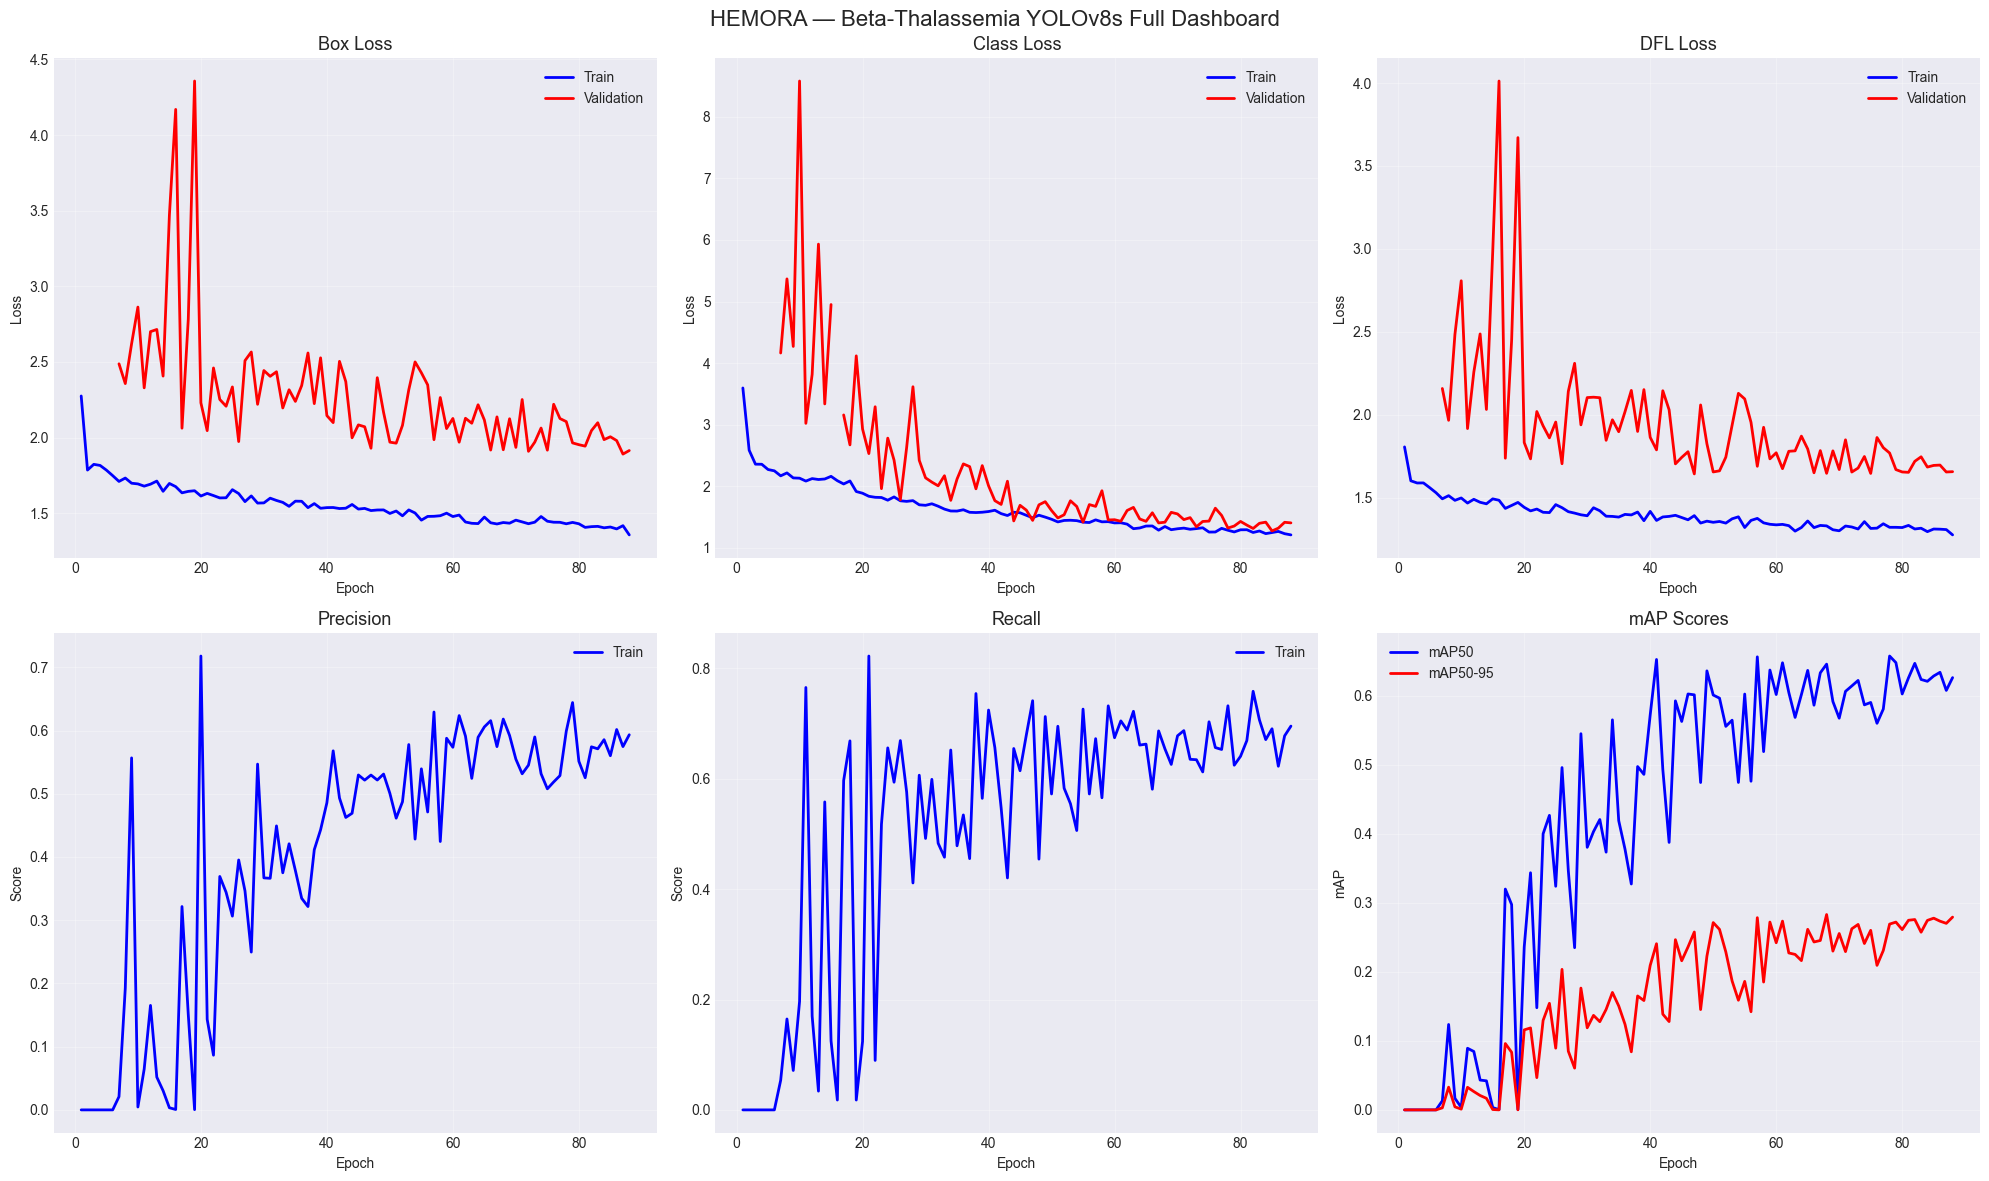

✅ Full dashboard saved!


In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(20, 12))
axes = axes.flatten()
plots = [
    ('train/box_loss',       'val/box_loss',        'Box Loss',   'Loss'),
    ('train/cls_loss',       'val/cls_loss',        'Class Loss', 'Loss'),
    ('train/dfl_loss',       'val/dfl_loss',        'DFL Loss',   'Loss'),
    ('metrics/precision(B)', None,                  'Precision',  'Score'),
    ('metrics/recall(B)',    None,                  'Recall',     'Score'),
    ('metrics/mAP50(B)',     'metrics/mAP50-95(B)', 'mAP Scores', 'mAP'),
]
for ax, (tc, vc, title, ylabel) in zip(axes, plots):
    if tc in df.columns:
        lbl = 'mAP50' if 'mAP50(B)' in tc and '95' not in tc else 'Train'
        ax.plot(epochs_range, df[tc], 'b-', label=lbl, linewidth=2)
    if vc and vc in df.columns:
        lbl2 = 'mAP50-95' if '95' in vc else 'Validation'
        ax.plot(epochs_range, df[vc], 'r-', label=lbl2, linewidth=2)
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_xlabel('Epoch'); ax.set_ylabel(ylabel)
    ax.legend(); ax.grid(True, alpha=0.3)

plt.suptitle('HEMORA — Beta-Thalassemia YOLOv8s Full Dashboard',
             fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{BASE_DIR}/graphs/yolo/training_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Full dashboard saved!')

In [ ]:
yolo_artifacts = [
    'confusion_matrix.png', 'confusion_matrix_normalized.png',
    'PR_curve.png', 'P_curve.png', 'R_curve.png',
    'F1_curve.png', 'results.png', 'labels.jpg',
]
for art in yolo_artifacts:
    src = f'{results_dir}/{art}'
    if os.path.exists(src):
        dst = (f'{BASE_DIR}/confusion_matrix/{art}'
               if 'confusion' in art
               else f'{BASE_DIR}/graphs/yolo/{art}')
        shutil.copy2(src, dst)
        print(f'✅ {art}')
    else:
        print(f'⚠️  {art} not found')
print('\n✅ YOLO artifacts copied to Drive!')

✅ confusion_matrix.png
✅ confusion_matrix_normalized.png
⚠️  PR_curve.png not found
⚠️  P_curve.png not found
⚠️  R_curve.png not found
⚠️  F1_curve.png not found
✅ results.png
✅ labels.jpg

✅ YOLO artifacts copied to Drive!


## ✅ STEP 9 — Save Per-Epoch Training Log

In [ ]:
timestamp    = datetime.now().strftime('%Y%m%d_%H%M%S')
df.to_csv(f'{BASE_DIR}/training_logs/yolo_epoch_log_{timestamp}.csv', index=False)

best_epoch   = int(df['metrics/mAP50(B)'].idxmax()) + 1
best_map50   = float(df['metrics/mAP50(B)'].max())
best_map5095 = float(df['metrics/mAP50-95(B)'].max())
best_prec    = float(df['metrics/precision(B)'].max())
best_rec     = float(df['metrics/recall(B)'].max())

summary = {
    'training_info': {
        'timestamp': timestamp,
        'model': 'YOLOv8s',
        'dataset': 'Beta-Thalassemia Minor',
        'class_order': {str(i): CLASS_NAMES[i] for i in range(NUM_CLASSES)},
        'total_epochs': len(df),
        'training_time_minutes': round(training_time/60, 2),
    },
    'hyperparameters': {
        'epochs': EPOCHS, 'batch': BATCH_SIZE,
        'imgsz': IMG_SIZE, 'lr0': LR0, 'lrf': LRF,
        'optimizer': 'AdamW', 'patience': PATIENCE,
    },
    'best_results': {
        'best_epoch': best_epoch,
        'mAP50':      round(best_map50,   4),
        'mAP50_95':   round(best_map5095, 4),
        'precision':  round(best_prec,    4),
        'recall':     round(best_rec,     4),
    },
}

with open(f'{BASE_DIR}/training_logs/yolo_summary_{timestamp}.json', 'w') as f:
    json.dump(summary, f, indent=4)

print('='*55)
print('YOLOV8s TRAINING SUMMARY')
print('='*55)
print(f'Class Order    : {CLASS_NAMES}')
print(f'Total Epochs   : {len(df)}')
print(f'Training Time  : {training_time/60:.1f} min')
print(f'Best Epoch     : {best_epoch}')
print(f'Best mAP@50    : {best_map50*100:.1f}%')
print(f'Best mAP@50-95 : {best_map5095*100:.1f}%')
print(f'Best Precision : {best_prec:.4f}')
print(f'Best Recall    : {best_rec:.4f}')
print('='*55)
print('✅ Log saved to Drive!')

YOLOV8s TRAINING SUMMARY
Class Order    : ['hypochromic_cell', 'microcyte', 'target_cell']
Total Epochs   : 88
Training Time  : 10.2 min
Best Epoch     : 78
Best mAP@50    : 65.7%
Best mAP@50-95 : 28.3%
Best Precision : 0.7179
Best Recall    : 0.8226
✅ Log saved to Drive!


## ✅ STEP 10 — Save Best Model to Google Drive

In [ ]:
best_pt = f'{results_dir}/weights/best.pt'
last_pt = f'{results_dir}/weights/last.pt'

if os.path.exists(best_pt):
    shutil.copy2(best_pt, f'{BASE_DIR}/models/yolo/best_yolov8s_{timestamp}.pt')
    shutil.copy2(best_pt, f'{BASE_DIR}/models/yolo/best_model.pt')
    print(f'✅ Best model saved! Size: {os.path.getsize(best_pt)/1e6:.1f} MB')

if os.path.exists(last_pt):
    shutil.copy2(last_pt, f'{BASE_DIR}/models/yolo/last_yolov8s_{timestamp}.pt')
    print(f'✅ Last model saved!')

best_model = YOLO(best_pt)
print('\n✅ Best model loaded for inference!')

✅ Best model saved! Size: 22.5 MB
✅ Last model saved!

✅ Best model loaded for inference!


## ✅ STEP 11 — Run Predictions on Test Images

Running on 3 images...
Class order used: ['hypochromic_cell', 'microcyte', 'target_cell']
✅ 3 prediction images saved to Drive!


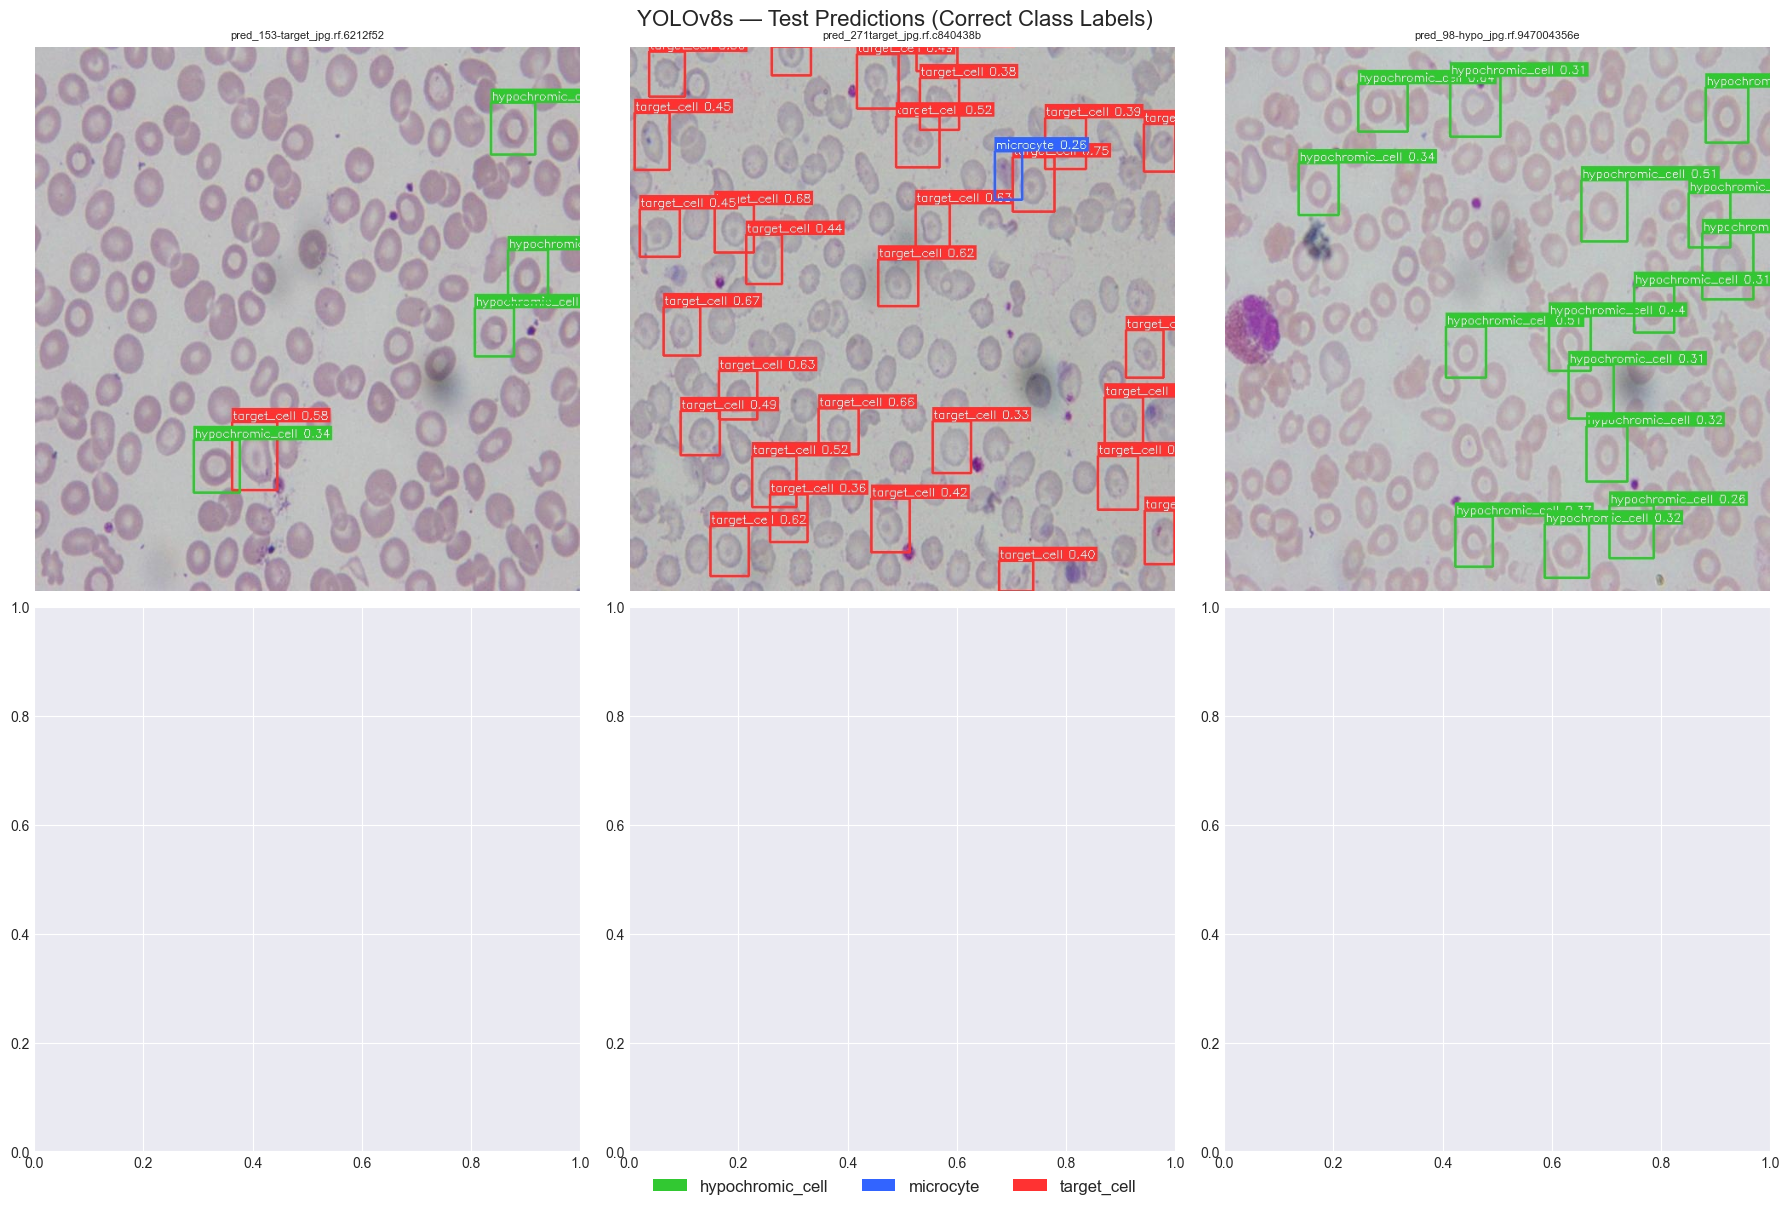

✅ Prediction grid saved to Drive!


In [ ]:
test_img_dir = f'{yaml_dir}/test/images'
if not os.path.exists(test_img_dir):
    test_img_dir = f'{yaml_dir}/valid/images'

test_images = [f for f in os.listdir(test_img_dir)
               if f.endswith(('.jpg','.jpeg','.png'))]
print(f'Running on {len(test_images)} images...')
print(f'Class order used: {CLASS_NAMES}')

# ── CORRECT COLOR MAPPING ──
# 0=hypochromic_cell → Green
# 1=microcyte        → Blue
# 2=target_cell      → Red
COLORS_DRAW = {
    0: (50,  200, 50),   # hypochromic_cell → Green
    1: (50,  100, 255),  # microcyte        → Blue
    2: (255, 50,  50),   # target_cell      → Red
}

os.makedirs(f'{BASE_DIR}/predictions/yolo', exist_ok=True)

for img_file in test_images[:10]:
    img_path = f'{test_img_dir}/{img_file}'
    img      = cv2.cvtColor(cv2.imread(img_path), cv2.COLOR_BGR2RGB)
    h, w     = img.shape[:2]
    pred     = best_model(img_path, conf=0.25, iou=0.45, verbose=False)[0]
    ann      = img.copy()

    if pred.boxes is not None:
        for box in pred.boxes:
            cls_id = int(box.cls[0])
            conf   = float(box.conf[0])
            x1,y1,x2,y2 = map(int, box.xyxy[0])
            c = COLORS_DRAW.get(cls_id, (255,255,0))

            cv2.rectangle(ann, (x1,y1), (x2,y2), c, 2)

            label = f'{CLASS_NAMES[cls_id]} {conf:.2f}'
            (lw, lh), _ = cv2.getTextSize(label, cv2.FONT_HERSHEY_SIMPLEX, 0.45, 1)
            cv2.rectangle(ann, (x1, y1-lh-6), (x1+lw+2, y1), c, -1)
            cv2.putText(ann, label, (x1+1, y1-3),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.45, (255,255,255), 1)

    out_bgr = cv2.cvtColor(ann, cv2.COLOR_RGB2BGR)
    cv2.imwrite(f'{BASE_DIR}/predictions/yolo/pred_{img_file}', out_bgr)

print(f'✅ {min(10, len(test_images))} prediction images saved to Drive!')

# Show prediction grid
saved = sorted([f for f in os.listdir(f'{BASE_DIR}/predictions/yolo')
                if f.startswith('pred_')])[:6]
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

for idx, fname in enumerate(saved):
    img = cv2.cvtColor(
        cv2.imread(f'{BASE_DIR}/predictions/yolo/{fname}'), cv2.COLOR_BGR2RGB)
    axes[idx].imshow(img)
    axes[idx].set_title(fname[:30], fontsize=8)
    axes[idx].axis('off')

# Legend with correct class-color mapping
legend_elements = [
    Patch(facecolor=[c/255 for c in COLORS_DRAW[i]], label=CLASS_NAMES[i])
    for i in range(NUM_CLASSES)
]
fig.legend(handles=legend_elements, loc='lower center',
           ncol=3, fontsize=12, bbox_to_anchor=(0.5, -0.02))

plt.suptitle('YOLOv8s — Test Predictions (Correct Class Labels)',
             fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{BASE_DIR}/graphs/yolo/sample_predictions.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Prediction grid saved to Drive!')

In [3]:
# ============================================================
# 🔍 DEMO — Upload Image & Check YOLO Detection
# ============================================================
!pip install ultralytics -q # Ensure ultralytics is installed
from google.colab import files
from ultralytics import YOLO # Import YOLO for model loading
import os # Import os module to check file existence

# Define BASE_DIR for standalone execution, if not already defined
# This should match the BASE_DIR defined in STEP 2 for consistency
BASE_DIR = '/content/drive/MyDrive/thalassemia_project'

print('📂 Upload a blood smear image for demo...')
demo_upload = files.upload()

if demo_upload:
    demo_path = list(demo_upload.keys())[0]
    print(f'\n🔍 Running YOLO detection on: {demo_path}')

    # Define the path to the best model in Google Drive
    model_path_in_drive = f'{BASE_DIR}/models/yolo/best_model.pt'

    best_model = None # Initialize best_model to None
    # Ensure best_model is loaded
    if os.path.exists(model_path_in_drive):
        try:
            best_model = YOLO(model_path_in_drive)
            print('✅ best_model loaded for demo!')
        except Exception as e: # Catch any exception during loading
            print(f"⚠️  Error loading YOLO model from {model_path_in_drive}: {e}")
            print("Please ensure Step 10 ('Save Best Model to Google Drive') was executed successfully and the file is not corrupted.")
    else:
        print(f"⚠️  Error: YOLO model not found at {model_path_in_drive}. ")
        print("Please ensure Step 10 ('Save Best Model to Google Drive') was executed successfully.")

    if best_model: # Only proceed if best_model was successfully loaded
        # Run prediction
        demo_pred = best_model(demo_path, conf=0.25, iou=0.45, verbose=False)[0]

        # Count detections
        class_counts = {name: 0 for name in CLASS_NAMES}
        if demo_pred.boxes is not None:
            for box in demo_pred.boxes:
                cls_id = int(box.cls[0])
                if cls_id < NUM_CLASSES:
                    class_counts[CLASS_NAMES[cls_id]] += 1

        total = sum(class_counts.values())

        # Draw annotated image
        img     = cv2.cvtColor(cv2.imread(demo_path), cv2.COLOR_BGR2RGB)
        h, w    = img.shape[:2]
        ann     = img.copy()

        COLORS_DRAW = {
            0: (50,  200, 50),   # hypochromic_cell → Green
            1: (50,  100, 255),  # microcyte        → Blue
            2: (255, 50,  50),   # target_cell      → Red
        }

        if demo_pred.boxes is not None:
            for box in demo_pred.boxes: # Corrected from 'demo.boxes' to 'demo_pred.boxes'
                cls_id = int(box.cls[0])
                conf   = float(box.conf[0])
                x1,y1,x2,y2 = map(int, box.xyxy[0])
                c = COLORS_DRAW.get(cls_id, (255,255,0))

                cv2.rectangle(ann, (x1,y1), (x2,y2), c, 2)

                label = f'{CLASS_NAMES[cls_id]} {conf:.2f}'
                (lw,lh),_ = cv2.getTextSize(label, cv2.FONT_HERSHEY_SIMPLEX, 0.5, 1)
                cv2.rectangle(ann, (x1, y1-lh-8), (x1+lw+4, y1), c, -1)
                cv2.putText(ann, label, (x1+2, y1-4),
                            cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255,255,255), 1)

        # Result bar at bottom
        overlay = ann.copy()
        cv2.rectangle(overlay, (0, h-100), (w, h), (0,0,0), -1)
        cv2.addWeighted(overlay, 0.6, ann, 0.4, 0, ann)
        cv2.putText(ann,
                    f'target_cell:{class_counts["target_cell"]}  '
                    f'hypochromic:{class_counts["hypochromic_cell"]}  '
                    f'microcyte:{class_counts["microcyte"]}',
                    (10, h-60), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255,255,255), 2)
        cv2.putText(ann, f'Total Abnormal Cells Detected: {total}',
                    (10, h-20), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (200,200,200), 1)

        # Show result
        plt.figure(figsize=(14, 9))
        plt.imshow(ann)
        plt.title(f'HEMORA — YOLO Detection Result | {total} cells found',
                  fontsize=14, fontweight='bold')
        plt.axis('off')
        plt.tight_layout()
        plt.savefig(f'{BASE_DIR}/predictions/yolo/demo_{demo_path}', dpi=150)
        plt.show()

        # Print summary
        print('\n' + '='*50)
        print('DETECTION RESULTS')
        print('='*50)
        print(f'  🔴 target_cell      : {class_counts["target_cell"]}')
        print(f'  🟢 hypochromic_cell : {class_counts["hypochromic_cell"]}')
        print(f'  🔵 microcyte        : {class_counts["microcyte"]}')
        print(f'  ─────────────────────')
        print(f'  Total Abnormal Cells: {total}')
        print('='*50)
        print(f'\n✅ Result saved to Drive!')
    else:
        print("\nDemo skipped: YOLO model could not be loaded.")

📂 Upload a blood smear image for demo...


Saving image-4.png to image-4 (1).png

🔍 Running YOLO detection on: image-4 (1).png
✅ best_model loaded for demo!


NameError: name 'CLASS_NAMES' is not defined